# Instability of Parameter Estimates

A parameter is anything that a model uses to constrain its predictions. Commonly, a parameter is a quantity that describes a data set or distribution. A distribution *parameterized* by a parameter. For example:  
- If the mean of a normal distribution is a parameter; in fact, we say that a normal distribution is **parameterized** by its mean and variance.
- If we take the mean of a set of samples drawn from the normal distribution, we get an **estimate** of the mean of the underlying distribution (which is often assumed to be normal).  

Other parameters include the median, the correlation coefficient to another series, the standard deviation, and every other measurement of a data set.

**You Never Know, You Only Estimate**

When you take the mean of a data set, you do **not know** the mean. You have **estimated** the mean as best you can from the data you have. The estimate can be off. This is true of **any** parameter you estimate. To actually understand what is going on, you need to determine how good your estimate is by looking at its stability / standard error / confidence intervals.

#### Instability of Estimates

Whenever we consider a set of observations, our calculation of a parameter can only be an **estimate**. It will change as we take more measurements, as time passes and we get new observations, as the true underlying parameter changes, or as we look at different subsets of the data.

For instance, the **standard deviation** describes how different the mean of a set is from the value of each observation—that is, how far each observation is from the mean itself. In financial applications, data often comes in **time series**. In this case, we can estimate a parameter at different points in time—for example, using the previous 30 days as our sample. By looking at how much this moving estimate fluctuates as we change the time window, we can compute the instability of our moving estimate of the parameter.

In [39]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.stats.stattools import jarque_bera
from matplotlib import pyplot as plt

#### Example: Mean and Standard Deviation

First, let us take a look at some samples from a normal distribution. We know that the mean of the distribution is 0 and the standard deviation is 1; but if we measure the parameters from our observations, we will get only **approximately 0** and **approximately 1**. We see how these estimates change as we take more and more samples:

In [32]:
# Set a seed
np.random.seed(50)

Let us generate a random normal distribution and from there, we will plot varying sample sizes

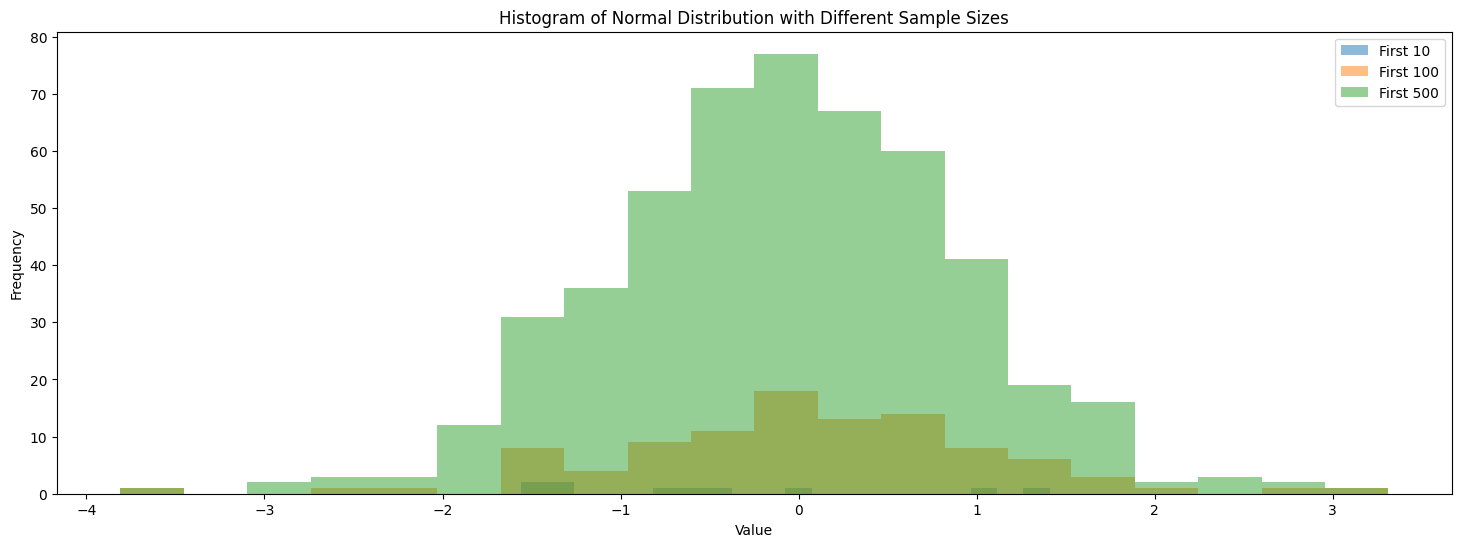

In [33]:
normal = np.random.randn(500)

# Plot a histogram of the normal distributions with different sample sizes and transparency
plt.figure(figsize=(18, 6))
plt.hist(normal[:10], bins=20, alpha=0.5, label='First 10')
plt.hist(normal[:100], bins=20, alpha=0.5, label='First 100')
plt.hist(normal[:500], bins=20, alpha=0.5, label='First 500')
plt.legend()
plt.title('Histogram of Normal Distribution with Different Sample Sizes')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

Let us observe the mean and standard deviation of the samples

In [34]:
print("Mean of first 10 samples:", np.mean(normal[:10]))
print("Mean of first 100 samples:", np.mean(normal[:100]))
print("Mean of first 500 samples:", np.mean(normal[:500]))

print("Standard Deviation of first 10 samples:", np.std(normal[:10]))
print("Standard Deviation of first 100 samples:", np.std(normal[:100]))
print("Standard Deviation of first 500 samples:", np.std(normal[:500]))

Mean of first 10 samples: -0.5061597618598521
Mean of first 100 samples: 0.04004115872112115
Mean of first 500 samples: -0.0797621489881377
Standard Deviation of first 10 samples: 0.9892509547776168
Standard Deviation of first 100 samples: 1.0762778842618
Standard Deviation of first 500 samples: 0.975551712999887


Notice that, although the probability of getting closer to 0 and 1 for the mean and standard deviation, respectively, increases with the number of samples, we do **not always** get better estimates by taking more data points. Whatever our expectation is, we can always get a different result, and our data is often so noisy that we usually care about the probability that the result is significantly different than expected.

With time series data, we usually care only about contiguous subsets of the data. The **moving average** (also called running or rolling) assigns the mean of the previous *n* data points to each point in time. Below, we compute the 90-day moving average of a stock price and plot it to see how it changes. There is no result in the beginning because we first have to accumulate at least 90 days of data.

#### Example: Non-Normal underlying Distribution

What happens if the underlying data is not normal? A mean will be very decptive and as such, it is important to test for normality of your data. For that we can use the Jarque-Bera test.

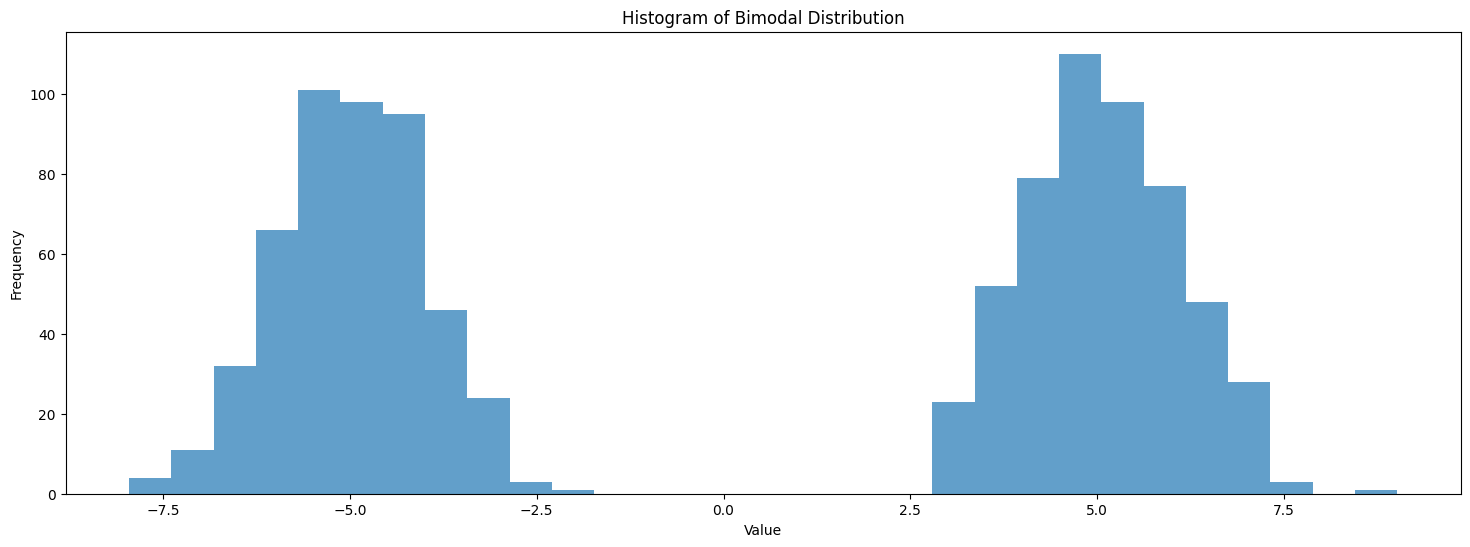

Mean of the bimodal distribution: 0.23275534412617854
Standard deviation of the bimodal distribution: 5.125447904071462


In [35]:
def bimodal(n):
  X = np.zeros(n)
  for i in range(n):
    if np.random.binomial(1, 0.5) == 0:
      X[i] = np.random.normal(-5, 1)
    else:
      X[i] = np.random.normal(5, 1)
  return X

X = bimodal(1000)

# Plot a histogram of the bimodal distribution
plt.figure(figsize=(18, 6))
plt.hist(X, bins=30, alpha=0.7)
plt.title('Histogram of Bimodal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

print("Mean of the bimodal distribution:", np.mean(X))
print("Standard deviation of the bimodal distribution:", np.std(X))

True enough, we can see that the mean is incredibly non-informative about what is going on in the data. We have collapsed all of our data into a single estimate and lost alot of information in doing so. This is what the distribution should look like if our hypothesis that it is normally distributed is correct.

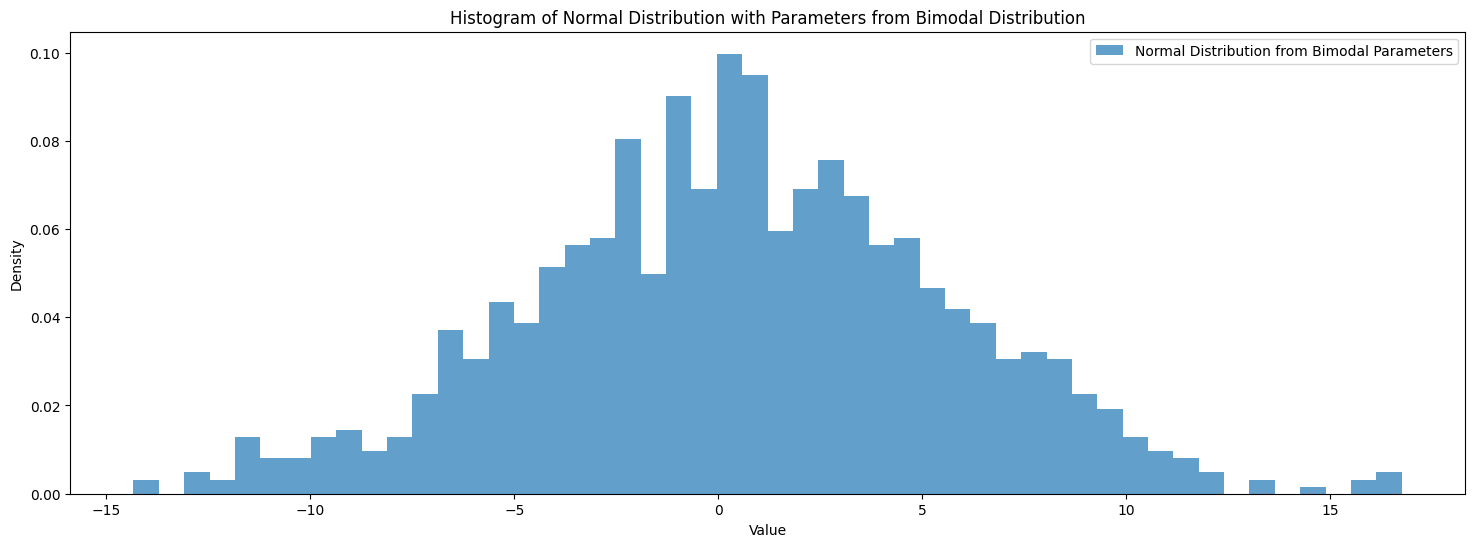

In [36]:
mu = np.mean(X)
sigma = np.std(X)

# Plot the histogram of the normal distrbution from the mean and std taken from the bimodal distribution
N = np.random.normal(mu, sigma, 1000)

# Plot a histogram of the normal distribution
plt.figure(figsize=(18, 6))
plt.hist(N, bins=50, alpha=0.7, density=True, label='Normal Distribution from Bimodal Parameters')
plt.title('Histogram of Normal Distribution with Parameters from Bimodal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

What we are illustrating here is that two fundamentally different distributions — one bimodal and one normal — can have exactly the same mean and standard deviation. Despite sharing these summary statistics, their shapes and underlying structures are completely different.

The danger lies in assuming a specific distribution (such as normality) and relying solely on the mean and standard deviation to model or estimate outcomes. If the true distribution differs from the assumption, the resulting inferences, risk estimates, and decisions can be significantly misleading.

**Running Normality Tests**

To really test if a distribution is normal, we can use in-built test libraries like **Jarque Bera**

In [38]:
print("p-value of the Jarque-Bera test for the bimodal distribution:", jarque_bera(X)[1])
if jarque_bera(X)[1] < 0.05:
  print("The bimodal distribution is not normally distributed.")
else:
  print("The bimodal distribution is normally distributed.")

p-value of the Jarque-Bera test for the bimodal distribution: 1.560597801012684e-31
The bimodal distribution is not normally distributed.


True enough, we show that from the Jarque Bera test, our p-value is <0.05, which means we can reject the null hypotheiss and have sufficient evidence that the distribution is not normal.

#### Example: Sharpe Ratio

One statistic often used to describe the performance of assets and portfolios is the **Sharpe ratio**, which measures the additional return per unit of additional risk achieved by a portfolio, relative to a risk-free source of return such as Treasury bills.

$$
R = \frac{E[r_a - r_b]}{\sqrt{\mathrm{Var}(r_a - r_b)}}
$$

where $r_a$ is the returns on our asset and $r_b$ is the risk-free rate of return.

As with mean and standard deviation, we can compute a **rolling Sharpe ratio** to see how our estimate changes through time.

In [42]:
def sharpe_ratio(asset, risk_free):
  return np.mean(asset - risk_free) / np.std(asset - risk_free)


start_date = '2010-01-01'
end_date = '2020-01-01'

# Use an ETF that tracks the 3 month US Treasury bill as the risk-free asset
symbol = 'BIL'
equity = 'AMZN'

# Download the data
data = yf.download([symbol, equity], start=start_date, end=end_date)['Close']

# Compute the daily returns
returns = data.pct_change().dropna()

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_4832/3720382650.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download([symbol, equity], start=start_date, end=end_date)['Close']
[*********************100%***********************]  2 of 2 completed


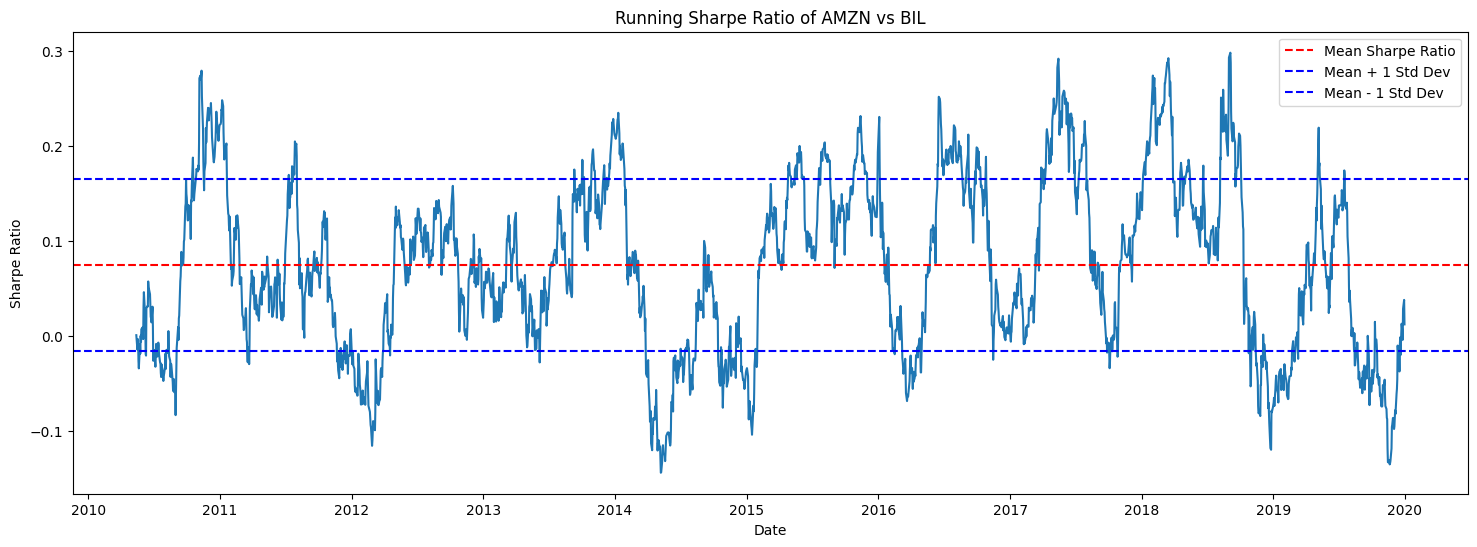

In [46]:
# Compute the running Sharpe ratio
treasury_returns = returns[symbol]
equity_returns = returns[equity]
sharpe_ratios = [sharpe_ratio(equity_returns[i-90:i], treasury_returns[i-90:i]) for i in range(90, len(returns))]

# Plot the running Sharpe ratio
plt.figure(figsize=(18, 6))
plt.plot(returns.index[90:], sharpe_ratios)
plt.title('Running Sharpe Ratio of AMZN vs BIL')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')

# Include the line for mean and 1 standard deviation of the Sharpe ratios
mean_sharpe = np.mean(sharpe_ratios)
std_sharpe = np.std(sharpe_ratios)
plt.axhline(mean_sharpe, color='red', linestyle='--', label='Mean Sharpe Ratio')
plt.axhline(mean_sharpe + std_sharpe, color='blue', linestyle='--', label='Mean + 1 Std Dev')
plt.axhline(mean_sharpe - std_sharpe, color='blue', linestyle='--', label='Mean - 1 Std Dev')
plt.legend()
plt.show()

The **standard deviation** in this case is about a quarter of the range, so this data is **extremely volatile**. Taking this into account when looking ahead gave a better prediction than just using the mean, although we still observed data more than one standard deviation away. We could also compute the **rolling mean** of the Sharpe ratio to try to follow trends, but in that case, too, we should keep in mind the standard deviation.

#### Example: Moving Average

Let's just say you take the average with a lookback window. How would you determine the standard error on that estimate? We can start with an example to show the 90-day moving average.

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_4832/705921932.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(equity, start=start_date, end=end_date)['Close']
[*********************100%***********************]  1 of 1 completed

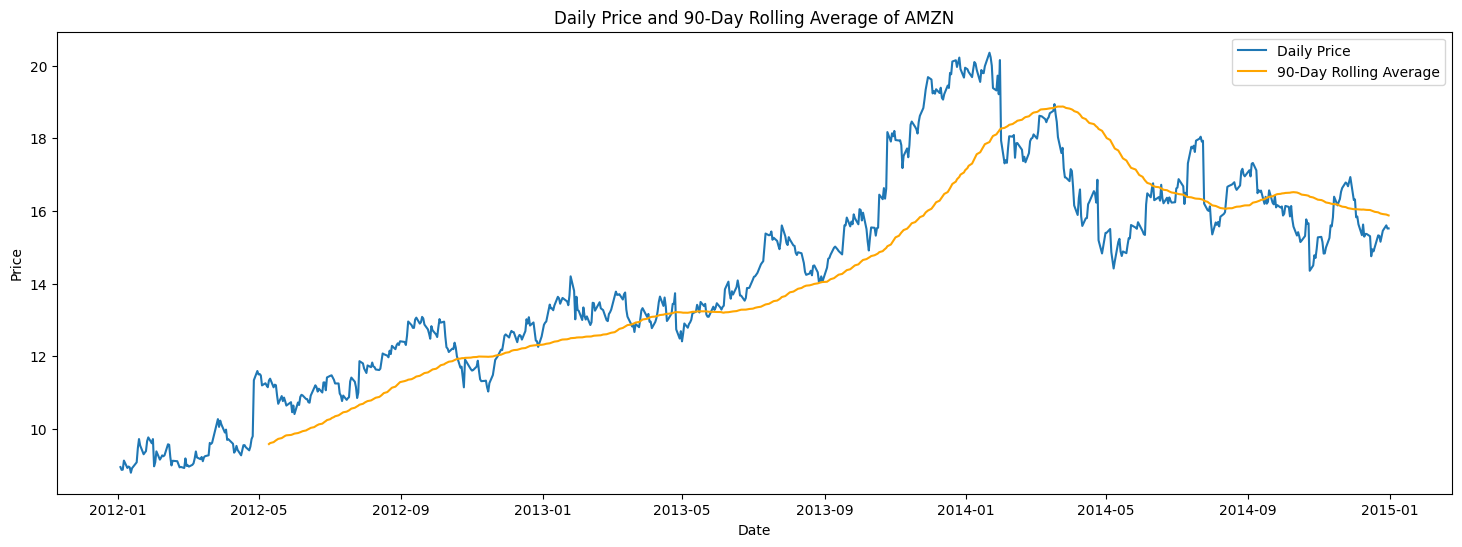

Mean of the rolling mean: 14.419316972447318
Standard deviation of the rolling mean: 2.5567575075803686


In [49]:
start_date = '2012-01-01'
end_date = '2015-01-01'

price_data = yf.download(equity, start=start_date, end=end_date)['Close']
# Compute the rolling average of the daily prices with a window of 90 days
rolling_avg = price_data.rolling(window=90).mean()

# Plot the pricing data and the rolling average
plt.figure(figsize=(18, 6))
plt.plot(price_data.index, price_data, label='Daily Price')
plt.plot(rolling_avg.index, rolling_avg, label='90-Day Rolling Average', color='orange')
plt.title('Daily Price and 90-Day Rolling Average of AMZN')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

print("Mean of the rolling mean:", np.mean(rolling_avg.dropna()))
print("Standard deviation of the rolling mean:", np.std(rolling_avg.dropna()[equity]))

Now let us compute the rolling standard deviation

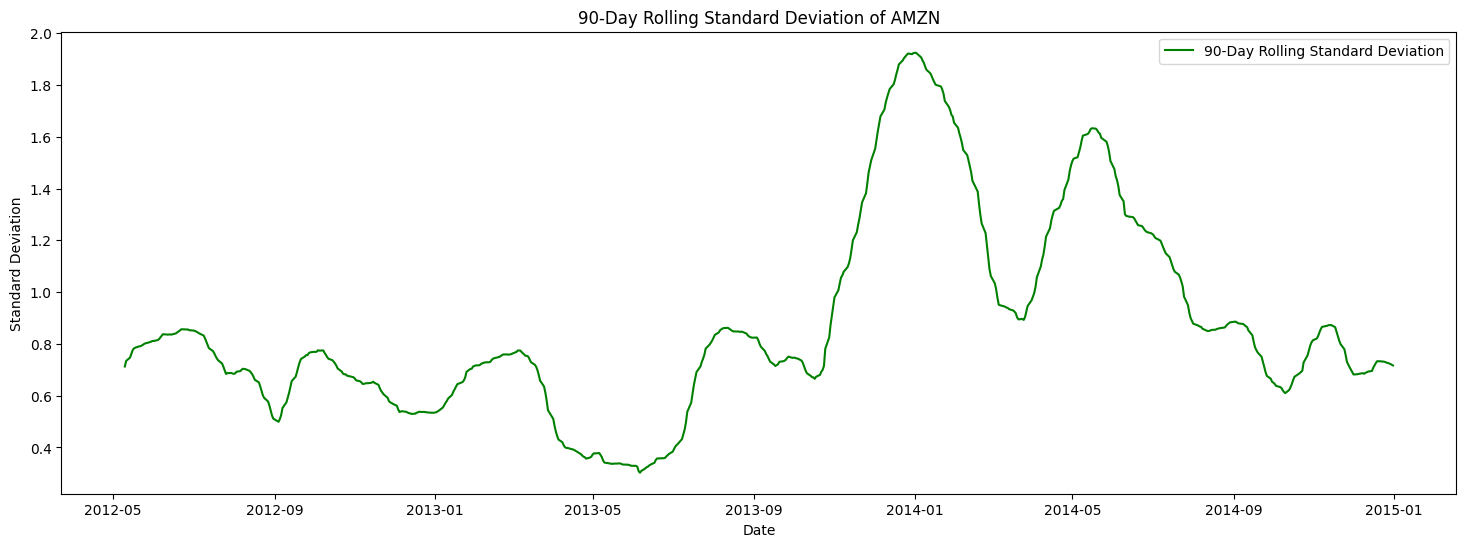

Mean of the rolling standard deviation: 0.8701913782700504
Standard deviation of the rolling standard deviation: 0.3772346255500084


In [51]:
rolling_standard_deviation = price_data.rolling(window=90).std()

# Plot the rolling standard deviation
plt.figure(figsize=(18, 6))
plt.plot(rolling_standard_deviation.index, rolling_standard_deviation, label='90-Day Rolling Standard Deviation', color='green')
plt.title('90-Day Rolling Standard Deviation of AMZN')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.legend()
plt.show()

print("Mean of the rolling standard deviation:", np.mean(rolling_standard_deviation.dropna()))
print("Standard deviation of the rolling standard deviation:", np.std(rolling_standard_deviation.dropna()[equity]))

The key thing to remember is that the standard deviation we calculate is itself an estimate. It is an estimate of the variability of an estimated quantity. That means it also carries uncertainty. If you track the standard deviation over time, you’ll notice that it fluctuates significantly — it has its own mean and its own standard deviation. In other words, even our measure of risk is unstable and uncertain.

The broader point is that almost everything in modelling and investing is an estimate, and every estimate comes with uncertainty. The goal is not to eliminate uncertainty — that’s impossible — but to drill down far enough, stress-test deeply enough, and analyze thoroughly enough that the remaining uncertainty is at a level you are comfortable with. That comfort level differs for everyone. It depends on your risk tolerance, the type of strategy you’re running, and how robust that strategy is across different possible underlying market conditions.

Note that although standard deviation gives us more information about the spread of the data, we cannot assign precise probabilities to our expectations for future pbservations without assuming a particulcr distribution for the underlying process.

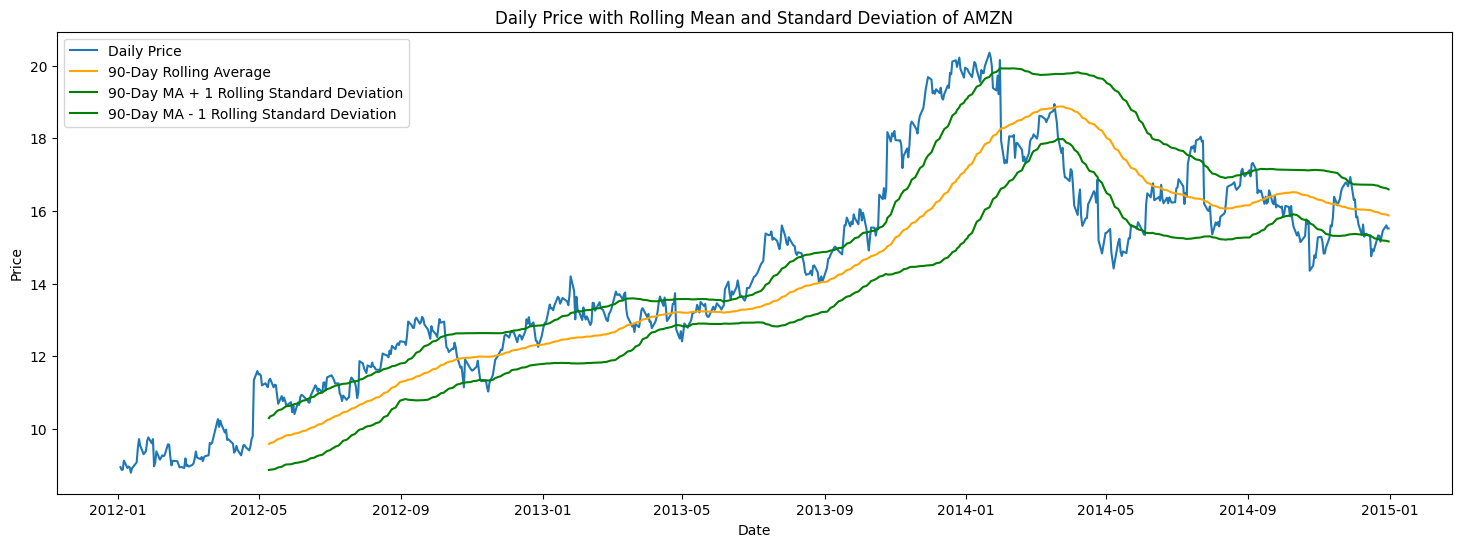

In [57]:
# Plot the original price data and incorporate the rolling mean and rolling standard deviation as shaded areas around the rolling mean
mask = rolling_avg.notna() & rolling_standard_deviation.notna()

plt.figure(figsize=(18, 6))
plt.plot(price_data.index, price_data, label='Daily Price')
plt.plot(rolling_avg.index, rolling_avg, label='90-Day Rolling Average', color='orange')
plt.plot(rolling_standard_deviation.index, rolling_avg + rolling_standard_deviation, label='90-Day MA + 1 Rolling Standard Deviation', color='green')
plt.plot(rolling_standard_deviation.index, rolling_avg - rolling_standard_deviation, label='90-Day MA - 1 Rolling Standard Deviation', color='green')
plt.title('Daily Price with Rolling Mean and Standard Deviation of AMZN')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

Remarks:

---

This final plot shows the moving average plus and minus one standard deviation. In effect, we’re saying: “If we (loosely) assume something like a normal distribution around the moving average” — which ideally should be tested — then this band represents a reasonable range of expected variation. Even if the distribution isn’t perfectly normal, this framework is still more informative than looking at the moving average alone. It gives us a range within which the underlying price is likely to fluctuate.

The practical question becomes: **Is your algorithm robust to prices moving anywhere within this band?**

If your strategy performs reasonably well across that entire range, then the moving average signal may be reliable enough to use. But if small deviations within that band break your strategy, then it’s fragile.

**Comparing Two Prices**

Similarly, if you're trying to determine whether two prices are meaningfully different, you shouldn’t compare just the point estimates (means). You need to consider their uncertainty. A useful way to think about it is: do the variance windows overlap?
- Is the highest plausible value of one price still below the lowest plausible value of the other?
- Or do their confidence ranges overlap?

If the ranges overlap substantially, the observed difference may just be noise or measurement error rather than a true difference. This is fundamentally the intuition behind hypothesis testing — such as a Z-test.

**The Core Principle**

The main takeaway is this: **never rely on single point estimates.** A moving average is not just a number — it is an estimate with variability. You should track how much that moving average itself fluctuates over time. The same applies to metrics like the Sharpe ratio. It is an estimate, and it has its own uncertainty. If you’re not measuring the variability of your estimates, you’re ignoring a major source of risk.